### В этом блокноте проводится EDA для корпуса данных SeniorTalk для построения основных зависимостей и распределений

Загрузка

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datasets import load_dataset
import IPython.display as ipd
from huggingface_hub import hf_hub_download
import librosa
import numpy as np
import seaborn as sns


/home/ext-ivanova-mk@ad.speechpro.com/test_dir/vox-profile_venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ds = load_dataset("evan0617/seniortalk", "sentence_data", split = "test")

Generating test split: 100%|██████████| 5869/5869 [00:27<00:00, 212.64 examples/s]


In [21]:
ds[0]

{'path': {'path': 'Elderly0014S0046W0001.wav',
  'array': array([-0.00013733, -0.00036621, -0.00028992, ...,  0.00047302,
         -0.00018311, -0.0004425 ]),
  'sampling_rate': 16000},
 'text': '哎呀，我一天。'}

In [22]:
len(ds)

5869

In [ ]:
player = ipd.Audio(ds[0]['path']['array'], rate=ds[0]['path']['sampling_rate'])
ipd.display(player)

Преобразование в удобный формат

In [ ]:
spkinfo = './datasets--evan0617--seniortalk/snapshots/d8f71863fff5d3128f806ca9025c653dd3dac397/'

In [ ]:
file_path = os.path.join(spkinfo, 'SPKINFO.txt')

df = pd.read_csv(file_path, sep='\t', header=0)

print(f"   Успешно загружено!")
print(f"   Строк: {len(df)}")
print(f"   Колонок: {len(df.columns)}")
print(f"   Колонки: {df.columns.tolist()}")


   Успешно загружено!
   Строк: 202
   Колонок: 4
   Колонки: ['SPEAKER_ID', 'GENDER', 'AGE', 'city           DEVICE']


In [7]:
df.head()

,SPEAKER_ID,GENDER,AGE,city DEVICE
0,1,M,81,北京 HUAWEI MGA-AL00
1,2,F,78,北京 HUAWEI MGA-AL00
2,3,F,77,浙江 HONOR AL10
3,4,F,76,浙江 HONOR AL10
4,5,F,76,北京 Iphone 13pro


Распределение по возрасту

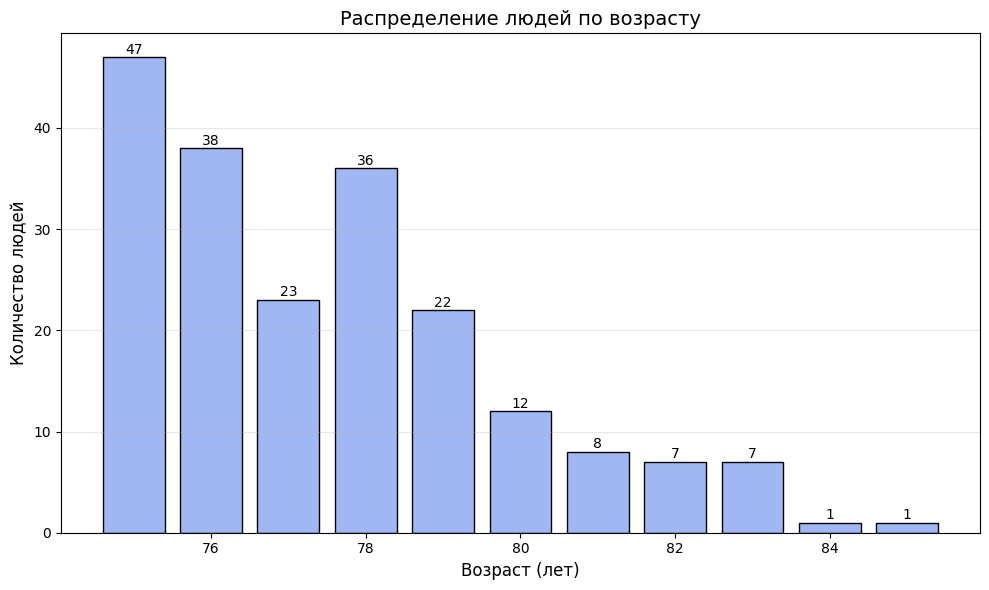


Статистика:

Всего людей: 202
Средний возраст: 77.5 лет
Медианный возраст: 77.0 лет
Возрастной диапазон: 75-85 лет


In [36]:
age_counts = df['AGE'].value_counts().sort_index()

# График
plt.figure(figsize=(10, 6))
plt.bar(age_counts.index, age_counts.values, color='#A1B7F4', edgecolor='black')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество людей', fontsize=12)
plt.title('Распределение людей по возрасту', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for age, count in age_counts.items():
    plt.text(age, count + 0.05, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Статистика
print(f"\nСтатистика:\n")
print(f"Всего людей: {len(df)}")
print(f"Средний возраст: {df['AGE'].mean():.1f} лет")
print(f"Медианный возраст: {df['AGE'].median():.1f} лет")
print(f"Возрастной диапазон: {df['AGE'].min()}-{df['AGE'].max()} лет")

Распределение по полу

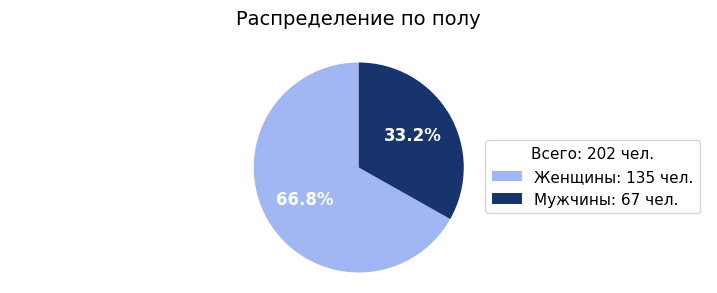

In [49]:
gender_counts = df['GENDER'].value_counts()

plt.figure(figsize=(9, 3))

colors = ['#A1B7F4', "#17346D"]
wedges, texts, autotexts = plt.pie(gender_counts.values, 
                                    labels=None,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})

plt.legend(wedges, 
           [f'Женщины: {gender_counts.get("F", 0)} чел.', 
            f'Мужчины: {gender_counts.get("M", 0)} чел.'],
           loc='upper right',
           bbox_to_anchor=(1, 0.65),  # Координаты внутри графика
           frameon=True,
           fontsize=11,
           title=f'Всего: {len(df)} чел.',
           title_fontsize=11)

plt.title('Распределение по полу', loc = 'center', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

Распределение по длительности

Найдено 5869 аудиозаписей в SeniorTalk


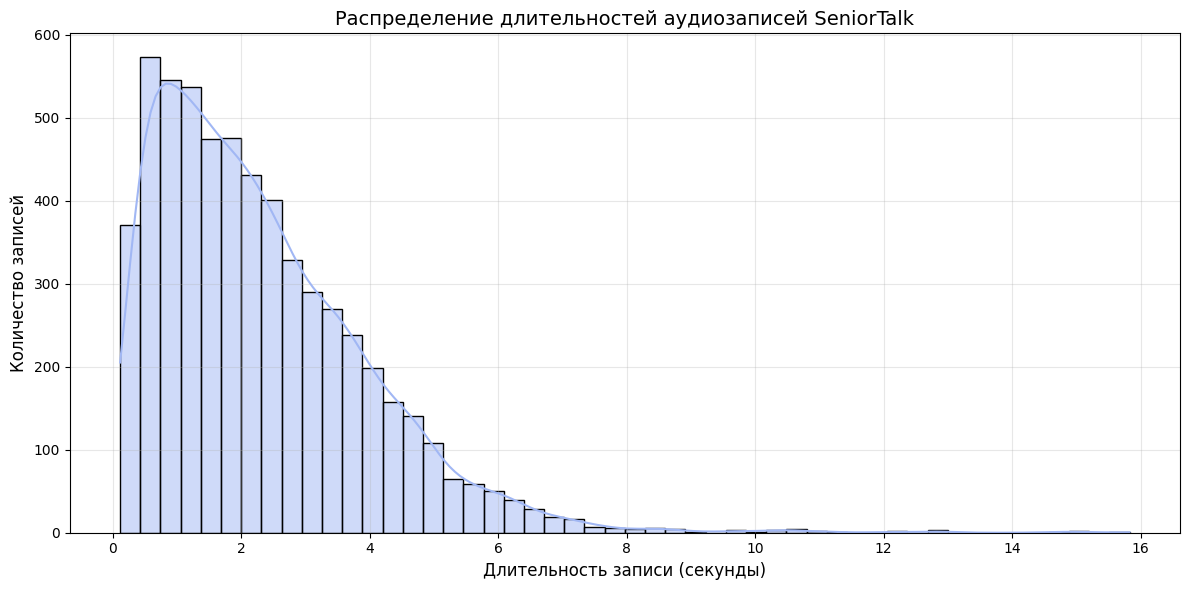


Минимальная длительность: 0.12 сек
Максимальная длительность: 15.82 сек
Средняя длительность: 2.31 сек
Медианная длительность: 1.98 сек


In [40]:
ds = load_dataset("evan0617/seniortalk", "sentence_data", split="test")

print(f"Найдено {len(ds)} аудиозаписей в SeniorTalk")

durations = []
for i in range(len(ds)):
    try:
        audio_array = ds[i]['path']['array']
        sampling_rate = ds[i]['path']['sampling_rate']
        duration = len(audio_array) / sampling_rate
        durations.append(duration)
    except Exception as e:
        print(f"Ошибка при обработке записи {i}: {e}")
        continue

plt.figure(figsize=(12, 6))
sns.histplot(durations, bins=50, kde=True, color='#A1B7F4')
plt.xlabel('Длительность записи (секунды)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение длительностей аудиозаписей SeniorTalk', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nМинимальная длительность: {min(durations):.2f} сек")
print(f"Максимальная длительность: {max(durations):.2f} сек")
print(f"Средняя длительность: {np.mean(durations):.2f} сек")
print(f"Медианная длительность: {np.median(durations):.2f} сек")

### Выводы
#### При проведении первичного анализа набора данных SeniorTalk были выявлены следующие закономерности:
- Возрастной диапазон колеблется от 75 до 85 лет;
- В выборке преобладают женские голоса, которые  составляют 66.8% от общего количества;
- При анализе распределения длительностей аудиозаписей выявлено, что средняя продолжительность составляет 2.3 секунды, а сами длительности колеблются от 0.12 с. до 15.82 с.